## Project exam PfL Villa Alessandra (matr. 5405075)

# Characterization study: Mahlberg's approach 

Michaela Mahlberg is a German corpus linguist.  A large part of her research focuses on the language of Dickens’s novels, literary linguistics, children literature and discourse analysis. She applied scalable reading to investigate the construction of characters in readers' minds working on a selected corpus of classic fiction and children's books. 

By analysing patterns found through quantitative analysis and close reading, she was able to study the characterization process of important figures of classic literature such as Mr. Dick of "David Copperfield".

The aim of this code is to collect the quantitative data to investigate how anthropomorphized characters and more in general human characters are built in children's literature.


## Collecting data

As first step, the books must be collected and stored on our local machine; in this case the following books have been collected from the Project Gutenberg page:
- The Jungle book by Rudyard Kipling
- The Book of dragons by Edith Nesbit
- Alice in Wondreland by Lewis Carroll
- Little Women by Louisa May Alcott
- The Secret garden by Frances H. Burnett
- Anne of Green Gables by Lucy M. Montgomery
- Peter Pan by J.M. Barrie
- Winnie the Pooh by A.A. Milne

In [3]:
import re
import requests

urls = [
    "https://www.gutenberg.org/cache/epub/236/pg236.txt",  # The Jungle Book
    "https://www.gutenberg.org/cache/epub/23661/pg23661.txt",# The Book of Dragons
    "https://www.gutenberg.org/cache/epub/11/pg11.txt", # Alice in Wonderland
    "https://www.gutenberg.org/cache/epub/37106/pg37106.txt", #Little Women
    "https://www.gutenberg.org/cache/epub/113/pg113.txt",  #The Secret Garden
    "https://www.gutenberg.org/cache/epub/45/pg45.txt", # Anne of Green Gables
    "https://www.gutenberg.org/cache/epub/16/pg16.txt", # Peter Pan
    "https://www.gutenberg.org/cache/epub/67098/pg67098.txt" # Winnie the Pooh
]


def clean_text(text: str) -> str:
    """Cleans Project Gutenberg header and footer from text."""
    start_pattern = (
        r"\*\*\*\s*START OF TH(IS|E) PROJECT GUTENBERG EBOOK.*?\*\*\*"
    )
    end_pattern = r"\*\*\*\s*END OF TH(IS|E) PROJECT GUTENBERG EBOOK.*?\*\*\*"

    start_match = re.search(start_pattern, text, re.IGNORECASE)
    end_match = re.search(end_pattern, text, re.IGNORECASE)

    start_idx = start_match.end() if start_match else 0
    end_idx = end_match.start() if end_match else len(text)

    return text[start_idx:end_idx].strip()


def books_download(list_url):
    number = 1
    for url in list_url:
        r = requests.get(url)
        cleaned_content = clean_text(r.text)

        file_name = f"book_{number}.txt"
        with open(file_name, "w", encoding="utf-8") as file:
            file.write(cleaned_content)

        print(
            f"Saved {file_name} and counts ({len(cleaned_content)} characters)!"
        )
        number += 1


books_download(urls)


Saved book_1.txt and counts (278405 characters)!
Saved book_2.txt and counts (232601 characters)!
Saved book_3.txt and counts (147978 characters)!
Saved book_4.txt and counts (1093373 characters)!
Saved book_5.txt and counts (438120 characters)!
Saved book_6.txt and counts (571923 characters)!
Saved book_7.txt and counts (261841 characters)!
Saved book_8.txt and counts (133198 characters)!


## Displaying KWIC

The first part of Mahlberg's research consists in performing close reading on concordances displaying as KWIC the name of the characters that must be studied. The library NLTK, a toolkit for language procesisng, has been used to conduct this passage.

In [2]:
from contextlib import redirect_stdout
import nltk
from nltk.text import Text


def generates_kwic(file_name, word, final_file):
    with open(file_name, "r", encoding="utf-8") as f:
        text = f.read()

    words = nltk.word_tokenize(text.lower())
    object_text = Text(words)

    with open(final_file, "w", encoding="utf-8") as out_file:
        with redirect_stdout(out_file):
            
            object_text.concordance(word.lower(), lines=len(words))

    print(f"Concordances for '{word}' saved in {final_file}")


generates_kwic("book_1.txt", "Mowgli", "concordances_mowgli.txt")
generates_kwic("book_2.txt", "Dragon", "concordances_dragon.txt")
generates_kwic("book_3.txt", "Alice", "concordances_alice.txt")
generates_kwic("book_4.txt", "Jo", "concordances_jo.txt")
generates_kwic("book_5.txt", "Mary", "concordances_mary.txt")
generates_kwic("book_6.txt", "Anne", "concordances_anne.txt")
generates_kwic("book_7.txt", "Wendy", "concordances_wendy.txt")
generates_kwic("book_8.txt", "Winnie", "concordances_winnie.txt")

Concordances for 'Mowgli' saved in concordances_mowgli.txt
Concordances for 'Dragon' saved in concordances_dragon.txt
Concordances for 'Alice' saved in concordances_alice.txt
Concordances for 'Jo' saved in concordances_jo.txt
Concordances for 'Mary' saved in concordances_mary.txt
Concordances for 'Anne' saved in concordances_anne.txt
Concordances for 'Wendy' saved in concordances_wendy.txt
Concordances for 'Winnie' saved in concordances_winnie.txt


## Clusters

As next step Mahlberg suggests to collect clusters of the most common words associated with the name of the character we want to study. Again, NLTK has been leveraged to extract such clusters and tokenize the books

In [5]:
from collections import Counter
from nltk.util import ngrams
import nltk

def extract_character_clusters(file_name, target_word, n=4, top_k=15, output_file=None):
    with open(file_name, "r", encoding="utf-8") as f:
        text = f.read()

    tokens = nltk.word_tokenize(text)
    target_lower = target_word.lower()

    
    target_clusters = [
        " ".join(gram)
        for gram in ngrams(tokens, n)
        if any(w.lower() == target_lower for w in gram)
    ]

    cluster_freq = Counter(target_clusters)

    if output_file:
        with open(output_file, "w", encoding="utf-8") as out:
            out.write(f"=== Top {top_k} Character Clusters ({n}-grams) for '{target_word}' in {file_name} ===\n")
            for cluster, count in cluster_freq.most_common(top_k):
                out.write(f"{count:<5} | {cluster}\n")
        print(f"Cluster saved in '{output_file}'")

    return cluster_freq


targets_clusters = [
    ("book_1.txt", "Mowgli", "clusters_mowgli.txt"),
    ("book_2.txt", "Dragon", "clusters_dragon.txt"),
    ("book_3.txt", "Alice", "clusters_alice.txt"),
    ("book_4.txt", "Jo", "clusters_jo.txt"),
    ("book_5.txt", "Mary", "clusters_mary.txt"),
    ("book_6.txt", "Anne", "clusters_anne.txt"),
    ("book_7.txt", "Wendy", "clusters_wendy.txt"),
    ("book_8.txt", "Winnie", "clusters_winnie.txt"),
]

clusters_results = {}
for file_name, word, out_file in targets_clusters:
    var_name = f"{word.lower()}_clusters"
    clusters_results[var_name] = extract_character_clusters(
        file_name, word, n=4, top_k=15, output_file=out_file
    )

Cluster saved in 'clusters_mowgli.txt'
Cluster saved in 'clusters_dragon.txt'
Cluster saved in 'clusters_alice.txt'
Cluster saved in 'clusters_jo.txt'
Cluster saved in 'clusters_mary.txt'
Cluster saved in 'clusters_anne.txt'
Cluster saved in 'clusters_wendy.txt'
Cluster saved in 'clusters_winnie.txt'


In [29]:
SEMANTIC_FIELDS = {
    "Movement": {
        "said",
        "say",
        "walked",
        "walk",
        "ran",
        "run",
        "thought",
        "think",
        "looked",
        "look",
        "cried",
        "cry",
        "went",
        "go",
        "came",
        "come",
    },
    "Body": {
        "eye",
        "eyes",
        "hand",
        "hands",
        "paw",
        "paws",
        "head",
        "heads",
        "voice",
        "voices",
        "face",
        "faces",
        "ear",
        "ears",
        "foot",
        "feet",
    },
}


def analyze_semantic_categories(clusters):
    category_counts = {cat: 0 for cat in SEMANTIC_FIELDS}
    for ngram, freq in clusters:
        for word in ngram:
            for cat, lexicon in SEMANTIC_FIELDS.items():
                if word in lexicon:
                    category_counts[cat] += freq
    return category_counts



sem_categories = {}
for book_num, clusters in all_clusters.items():
    sem_categories[book_num] = analyze_semantic_categories(clusters)

sem_categories[6]

{'Movement': 14, 'Body': 4}

## Lexical Richness and Vocabulary Diversity Analysis

To evaluate and compare the stylistic complexity and vocabulary richness between *The Jungle Book* and *The Book of Dragons*, we implement four key quantitative metrics:

* **Type-Token Ratio (TTR):** Defined as $TTR = \frac{V}{N}$ (where $V$ represents the number of unique types and $N$ the total number of tokens). It measures raw vocabulary variation, though it tends to decrease in longer texts.
* **Root TTR (Guiraud's Index):** Calculated as $R = \frac{V}{\sqrt{N}}$, this index compensates for text-length variation, allowing a fairer comparison across corpora of different sizes.
* **Yule's Characteristic $K$:** A statistical indicator of vocabulary constancy based on word repetition probabilities. It is virtually independent of text length; lower $K$ values correspond to greater lexical diversity.
* **Hapax Legomena Ratio:** The percentage of words occurring exactly once in the text relative to total vocabulary size ($V_1 / V$). A higher proportion indicates greater stylistic originality and creative vocabulary choice.
* **MATTR:** A robust computational metric used to evaluate lexical diversity by calculating the ratio of unique words (types) to total words (tokens) within a fixed-size, word-by-word sliding window

,Document,Tokens (N),Types (V),TTR,Root TTR,MATTR,Hapax Ratio (%),Yule's K
0,The Jungle Book,50781,4436,0.0874,19.69,0.7056,43.96,108.76
1,The Book of Dragons,42221,3711,0.0879,18.06,0.6691,44.70,130.71
2,Alice in Wonderland,26357,2454,0.0931,15.12,0.6858,42.99,106.15
3,Little Women,189620,10455,0.0551,24.01,0.7370,40.16,85.55
4,The Secret Garden,80643,4698,0.0583,16.54,0.6953,42.27,83.05
5,Anne of Green Gables,104927,7292,0.0695,22.51,0.7173,44.65,82.47
6,Peter Pan,46956,4708,0.1003,21.73,0.7093,49.21,87.00
7,Winnie the Pooh,22489,1813,0.0806,12.09,0.6378,40.65,101.65


/tmp/ipykernel_9547/3869293004.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_9547/3869293004.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_9547/3869293004.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_9547/3869293004.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_9547/3869293004.py:139: UserWarning: set_tick

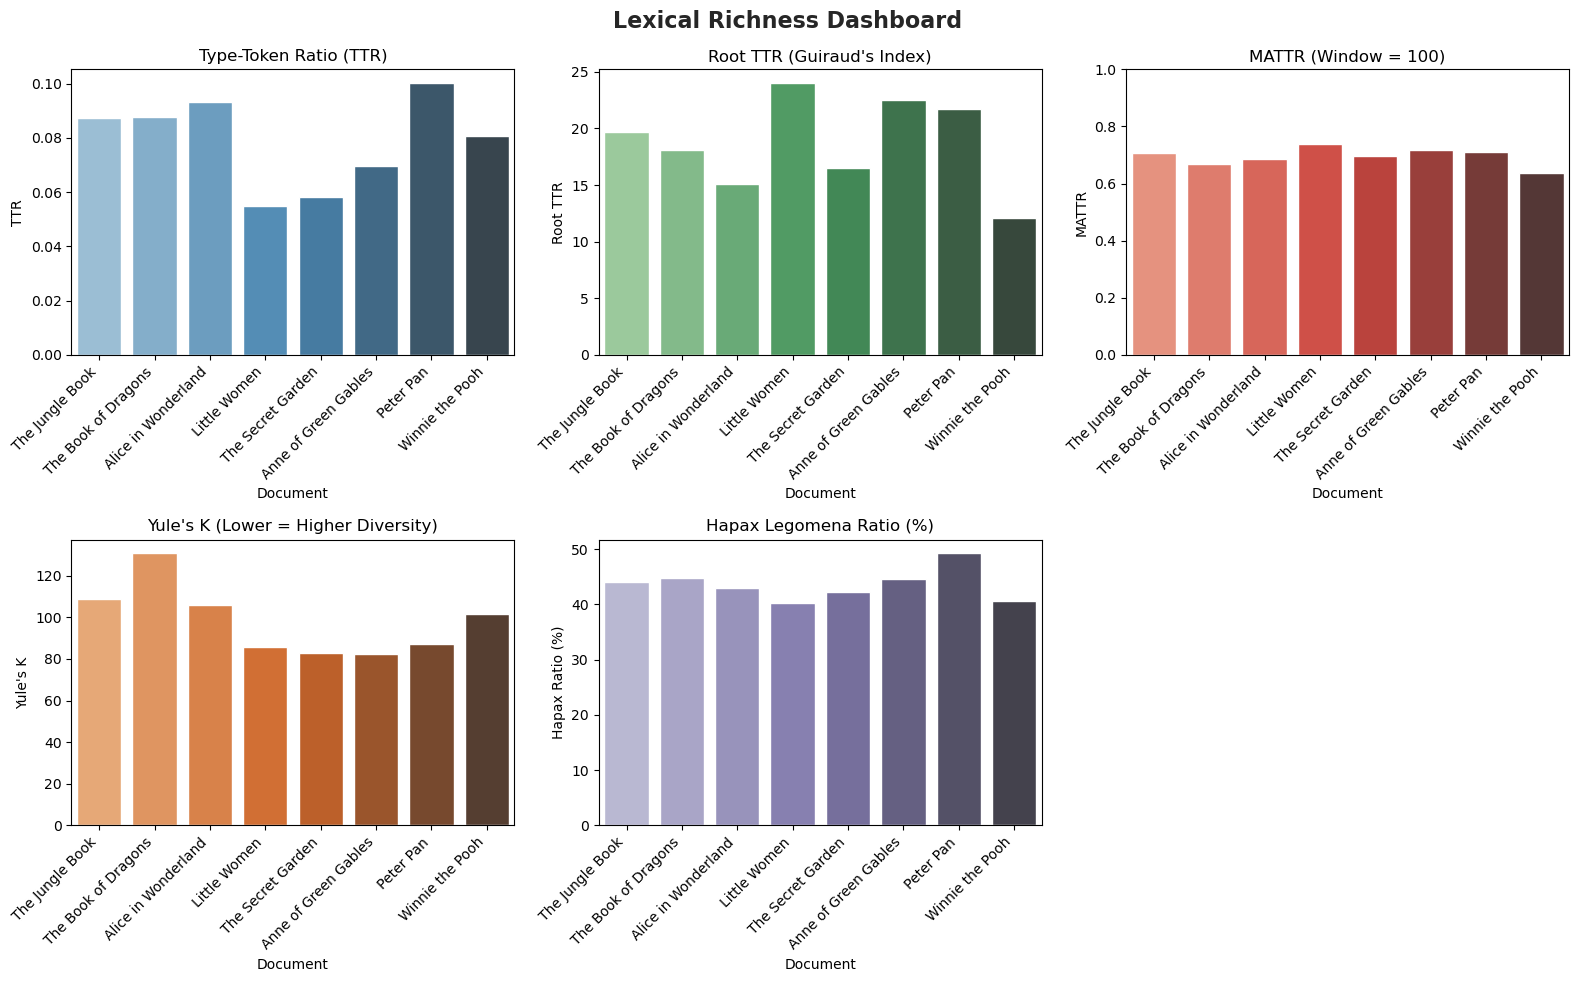

In [7]:
import math
from collections import Counter
import urllib.request
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


books = [
    ("book_1.txt", "The Jungle Book"),
    ("book_2.txt", "The Book of Dragons"),
    ("book_3.txt", "Alice in Wonderland"),
    ("book_4.txt", "Little Women"),
    ("book_5.txt", "The Secret Garden"),
    ("book_6.txt", "Anne of Green Gables"),
    ("book_7.txt", "Peter Pan"),
    ("book_8.txt", "Winnie the Pooh"),
]


# Tokenization
def load_words_nltk(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read().lower()

    
    tokens = nltk.word_tokenize(text)

    
    return [t for t in tokens if t.isalpha()]


def compute_lexical_metrics(tokens, doc_name, window_size=100):
    words = [t.lower() for t in tokens if t.isalpha()]
    N = len(words)
    freqs = Counter(words)
    V = len(freqs)

    # Type-Token Ratio (TTR)
    ttr = V / N if N > 0 else 0

    # Root TTR (Guiraud's Index)
    root_ttr = V / math.sqrt(N) if N > 0 else 0

    # Moving-Average TTR (MATTR)
    if N == 0:
        mattr = 0.0
    elif N < window_size:
        mattr = V / N
    else:
        ttr_sum = sum(
            len(set(words[i : i + window_size])) / window_size
            for i in range(N - window_size + 1)
        )
        mattr = ttr_sum / (N - window_size + 1)

    # Hapax Legomena Ratio (%)
    hapax_count = sum(1 for count in freqs.values() if count == 1)
    hapax_ratio = (hapax_count / V) * 100 if V > 0 else 0

    # Yule's K
    m1 = N
    m2 = sum(f**2 for f in freqs.values())
    yule_k = 10000 * (m2 - m1) / (m1**2) if m1 > 1 else 0

    return {
        "Document": doc_name,
        "Tokens (N)": N,
        "Types (V)": V,
        "TTR": round(ttr, 4),
        "Root TTR": round(root_ttr, 2),
        "MATTR": round(mattr, 4),
        "Hapax Ratio (%)": round(hapax_ratio, 2),
        "Yule's K": round(yule_k, 2),
    }


print("Downloading and analysing the books...")
metrics_list = [
    compute_lexical_metrics(load_words_nltk(url), title)
    for url, title in books
]

df_lex = pd.DataFrame(metrics_list)
display(df_lex)

# 5. Dashboard 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
sns.set_theme(style="whitegrid")
fig.suptitle("Lexical Richness Dashboard", fontsize=16, fontweight="bold", y=0.98)

# Subplot 1: TTR
sns.barplot(
    data=df_lex, x="Document", y="TTR", hue="Document",
    legend=False, ax=axes[0, 0], palette="Blues_d"
)
axes[0, 0].set_title("Type-Token Ratio (TTR)")

# Subplot 2: Root TTR
sns.barplot(
    data=df_lex, x="Document", y="Root TTR", hue="Document",
    legend=False, ax=axes[0, 1], palette="Greens_d"
)
axes[0, 1].set_title("Root TTR (Guiraud's Index)")

# Subplot 3: MATTR
sns.barplot(
    data=df_lex, x="Document", y="MATTR", hue="Document",
    legend=False, ax=axes[0, 2], palette="Reds_d"
)
axes[0, 2].set_title("MATTR (Window = 100)")
axes[0, 2].set_ylim(0, 1)

# Subplot 4: Yule's K
sns.barplot(
    data=df_lex, x="Document", y="Yule's K", hue="Document",
    legend=False, ax=axes[1, 0], palette="Oranges_d"
)
axes[1, 0].set_title("Yule's K (Lower = Higher Diversity)")

# Subplot 5: Hapax Ratio (%)
sns.barplot(
    data=df_lex, x="Document", y="Hapax Ratio (%)", hue="Document",
    legend=False, ax=axes[1, 1], palette="Purples_d"
)
axes[1, 1].set_title("Hapax Legomena Ratio (%)")


axes[1, 2].axis("off")


for ax in axes.flat:
    if ax.axison:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Collostruction analysis

# Gries' and Stefanowitsch's approach 

For the second part of the collection of quantitative data we need to PoS tag and parse the two books. The idea is to calculate simple collostructions to investigate which are the most frequent subjects in the construction Nom_subj + modal verb + infinitive verb


In [ ]:
import time
import stanza
from stanza.utils.conll import CoNLL

# Initialize the pipeline
nlp_stanza = stanza.Pipeline(
    'en', processors='tokenize,pos,depparse,lemma,ner'
)


def process_and_export_conll(input_file, output_conll, pipeline=nlp_stanza):
   
    with open(input_file, "r", encoding="utf-8") as f:
        text = f.read()

    print(
        f"Starting the elaboration of '{input_file}' ({len(text)} tokens)..."
    )

    
    start = time.time()
    doc = pipeline(text)
    end = time.time()

    elapsed = end - start
    print(f"Elaboration completed in {elapsed:.2f} seconds.")

    # File CoNLL
    CoNLL.write_doc2conll(doc, output_conll)
    print(f"File saved with success: '{output_conll}'\n")

    return doc






2026-09-21 16:47:29 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-09-21 16:47:30 INFO: Downloaded file to /home/alessandra/.cache/stanza/1.11.0/resources/resources.json
2026-09-21 16:47:30 WARNING: Language en package default expects mwt, which has been added
2026-09-21 16:47:30 INFO: Loading these models for language: en (English):
| Processor | Package                   |
-----------------------------------------
| tokenize  | combined                  |
| mwt       | combined                  |
| pos       | combined_charlm           |
| lemma     | combined_nocharlm         |
| depparse  | combined_charlm           |
| ner       | ontonotes-ww-multi_charlm |

2026-09-21 16:47:31 INFO: Using device: cpu
2026-09-21 16:47:31 INFO: Loading: tokenize
2026-09-21 16:47:33 INFO: Loading: mwt
2026-09-21 16:47:33 INFO: Loading: pos
2026-09-21 16:47:34 INFO: Loading: lemma
2026-09-21 16:47:34 INFO: Loading: depparse
2026-09-21 16:47:34 INFO: Loading: ner
2026-09-21 16:47:35 INFO: Done loading processors!


Starting the elaboration of 'book_1.txt' (273029 tokens)...
Elaboration completed in 258.84 seconds.
File saved with success: 'jungle_stanza.conll'

Starting the elaboration of 'book_2.txt' (227783 tokens)...


## Grewpy

Grewpy is an official Python library that provides tools for Grew, a software system used in natural language processing (NLP) to manipulate linguistic structures like dependency syntax trees. It allows researchers and developers to run complex pattern-matching queries and count occurrences directly inside a Python environment using an OCaml-backed engine.

In [7]:
! pip install grewpy


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [8]:
# To know which version of Ocaml we are using

!ocamlc -v

The OCaml compiler, version 4.14.0
Standard library directory: /home/alessandra/.opam/grew/lib/ocaml


In [9]:
# Importing the libraries needed for pattern matching and counter with Grewpy

import grewpy
from grewpy import Corpus, CorpusDraft, Request, grew_web
from grewpy.grew_web import Grew_web

connected to port: 40523


In [10]:
grewpy.set_config("ud")

## Grewpy accepts three kinds of input: 
The path of a Conllu file, a list of paths and the content of a Conllu file; we will use the content of the Conllu file we have created above

In [11]:
corpus = Corpus("jungle_stanza.conll")

print(f"Total sentences of the corpus: {len(corpus)}")

Total sentences of the corpus: 3101


### Pattern Matching & Collostructional Analysis Methodology

To investigate modal construction preferences across both corpora, we combine dependency pattern matching via **Grewpy** with quantitative **Collostructional Analysis**.

#### Syntactic Pattern Definition
Using Universal Dependencies (UD), we extract all occurrences where a modal auxiliary (`Y`) depends on a base verb (`X`):
* **Main Verb ($X$):** Defined with POS tag `VERB` and feature `VerbForm=Inf`.
* **Modal Auxiliary ($Y$):** Defined with lemma belonging to the core modal set (`can`, `could`, `may`, `might`, `must`, `should`, `shall`, `will`, `would`).
* **Dependency Edge ($e$):** Subordinated via an `aux` relation ($X \xrightarrow{aux} Y$).

#### Statistical Evaluation
For every extracted `(Modal, Verb)` combination, we construct a $2 \times 2$ contingency table and perform **Fisher's Exact Test** to measure the attraction strength between the modal auxiliary and the infinitive verb:

$$\text{Collostruction Strength} = -\log_{10}(p\text{-value})$$

A pair is identified as statistically significant if $\text{Collostruction Strength} \ge 1.301$ (corresponding to $p < 0.05$).

In [12]:
ptrn = """pattern {
  S [ upos=NOUN|PROPN|PRON ];
  A [ upos=AUX, lemma="can"|"could"|"may"|"might"|"must"|"should"|"shall"|"will"|"would" ];
  V [ upos=VERB, VerbForm=Inf ];
  V -[nsubj]-> S;
  V -[aux]-> A;
}
"""


In [13]:
req = Request(ptrn)

## Argument "deco = True" 
It is used to add a flag to the nodes that match the pattern; this searches for all the occurrences of the pattern in the corpus


In [14]:

res = corpus.search(req, deco=True)

In [15]:
# Total number of matches in the corpus
len(res)

643

In [16]:
# Inspecting a random match: the output is a dictionary 
res[99]

{'sent_id': '2503',
 'matching': {'nodes': {'V': '20', 'S': '18', 'A': '19'}, 'edges': {}},
 'deco': 544}

In [17]:
s100 = corpus[res[99]['sent_id']]
deco = res[99]['deco']

In [18]:
type(s100)

grewpy.graph.Graph

In [19]:
# Converts the syntactic graph in a string automatically insterting HTML tags
s100.to_sentence(deco=deco)

'Above the noise of the water, as it swirled round the elephant’s legs, Little <span class="highlight">Toomai</span> <span class="highlight">could</span> <span class="highlight">hear</span> more splashing and some trumpeting both upstream and down--great grunts and angry snortings, and all the mist about him seemed to be full of rolling, wavy shadows. '

In [20]:
from IPython.display import HTML, display

html_content = """
<style>
    .highlight {
        color: red;
    }
</style>
"""

In [21]:
html_content += s100.to_sentence(deco=deco)
display(HTML(html_content))

In [22]:
import json
import uuid
from IPython.display import HTML, display


def display_interactive_tree_rich(graph, deco=None):
    """Renders the SVG tree and diplays the syntactic information.
    """
    unique_id = f"tree_{uuid.uuid4().hex[:8]}"
    svg_code = graph.to_svg(deco=deco) if deco else graph.to_svg()

    
    relations = []
    for head, edge_dict, dep in graph.triples():
        rel_label = (
            edge_dict.get("1", "") if isinstance(edge_dict, dict) else ""
        )
        relations.append({"head": head, "dep": dep, "rel": rel_label})

    
    nodes_data = {}
    for node_id in graph:
        node_info = graph[node_id]
        if isinstance(node_info, dict):
            parents = [
                f"Nodo {r['head']} (rel: {r['rel']})"
                for r in relations
                if r["dep"] == node_id
            ]
            children = [
                f"Nodo {r['dep']} (rel: {r['rel']})"
                for r in relations
                if r["head"] == node_id
            ]

            nodes_data[str(node_id)] = {
                "features": node_info,
                "parents": parents if parents else ["Root / Nessuno"],
                "children": children if children else ["Nessuno"],
            }

    json_data = json.dumps(nodes_data)

    html_code = f"""
    <style>
        #{unique_id} .svg-tree text {{ cursor: pointer; }}
        #{unique_id} .svg-tree text:hover {{ fill: #d9534f !important; font-weight: bold; }}
        #{unique_id} .tree-panel {{
            margin-top: 12px; padding: 12px; border: 1px solid #007bff;
            background: #f8f9fa; border-radius: 6px; font-family: sans-serif; font-size: 13px;
        }}
        #{unique_id} .badge {{
            display: inline-block; background: #e2e8f0; color: #2d3748;
            padding: 3px 7px; border-radius: 4px; margin: 2px; font-family: monospace;
        }}
    </style>

    <div id="{unique_id}">
        <div class="svg-tree">{svg_code}</div>
        <div class="tree-panel">
            <b style="color: #007bff;">Syntactic details of the node:</b>
            <div class="details-content" style="margin-top: 6px;">
                <i>Click on a node of the tree (ex. [V], [A], [S] or on the tokens) to extract features.</i>
            </div>
        </div>
    </div>

    <script>
    (function() {{
        const root = document.getElementById('{unique_id}');
        const nodesData = {json_data};
        const detailsDiv = root.querySelector('.details-content');

        root.querySelectorAll('.svg-tree text').forEach(el => {{
            el.addEventListener('click', (e) => {{
                e.stopPropagation();
                const txt = e.target.textContent.trim();
                
                // Research of corresponding nodes in the dictionary of the graph
                let matchedKey = null;
                let matchedNode = null;

                for (const [nodeId, data] of Object.entries(nodesData)) {{
                    if (nodeId === txt || data.features.wordform === txt || data.features.lemma === txt || data.features.upos === txt) {{
                        matchedKey = nodeId;
                        matchedNode = data;
                        break;
                    }}
                }}

                if (matchedNode) {{
                    let featsHtml = Object.entries(matchedNode.features)
                        .map(([k, v]) => `<span class="badge"><b>${{k}}</b>: ${{v}}</span>`)
                        .join(' ');
                    
                    detailsDiv.innerHTML = `
                        <div><b>ID Internal node:</b> <span class="badge">${{matchedKey}}</span></div>
                        <div style="margin: 6px 0;"><b>All Features UD:</b><br>${{featsHtml}}</div>
                        <div><b>Syntactic father (Head):</b> ${{matchedNode.parents.join(', ')}}</div>
                        <div><b>Direct dependencies (Children):</b> ${{matchedNode.children.join(', ')}}</div>
                    `;
                }} else {{
                    detailsDiv.innerHTML = `<div><b>Selected tag:</b> <span class="badge">${{txt}}</span></div>`;
                }}
            }});
        }});
    }})();
    </script>
    """
    display(HTML(html_code))

In [23]:
match = res[34]  
graph = corpus[match["sent_id"]]  
deco = match.get("deco", None)  


display_interactive_tree_rich(graph, deco=deco)

In [24]:
#Every relation can be represented through a triple (father_node, relation, son)
s100.triples()

[('52', FsEdge({'1': 'amod'}), '51'),
 ('52', FsEdge({'1': 'amod'}), '49'),
 ('52', FsEdge({'1': 'case'}), '48'),
 ('49', FsEdge({'1': 'punct'}), '50'),
 ('47', FsEdge({'1': 'obl'}), '52'),
 ('47', FsEdge({'1': 'cop'}), '46'),
 ('47', FsEdge({'1': 'mark'}), '45'),
 ('44', FsEdge({'1': 'xcomp'}), '47'),
 ('44', FsEdge({'1': 'nsubj'}), '41'),
 ('44', FsEdge({'1': 'cc'}), '38'),
 ('44', FsEdge({'1': 'punct'}), '37'),
 ('43', FsEdge({'1': 'case'}), '42'),
 ('41', FsEdge({'1': 'nmod'}), '43'),
 ('41', FsEdge({'1': 'det'}), '40'),
 ('41', FsEdge({'1': 'det', '2': 'predet'}), '39'),
 ('36', FsEdge({'1': 'amod'}), '35'),
 ('36', FsEdge({'1': 'cc'}), '34'),
 ('33', FsEdge({'1': 'conj'}), '36'),
 ('33', FsEdge({'1': 'amod'}), '32'),
 ('33', FsEdge({'1': 'cc'}), '28'),
 ('33', FsEdge({'1': 'amod'}), '27'),
 ('29', FsEdge({'1': 'punct'}), '31'),
 ('29', FsEdge({'1': 'punct'}), '30'),
 ('27', FsEdge({'1': 'conj'}), '29'),
 ('27', FsEdge({'1': 'cc', '2': 'preconj'}), '26'),
 ('25', FsEdge({'1': 'obj

In [25]:
# This pattern does not require the explicit presence of a subject, making the search more general 
mod_ptrn = '''
pattern { X [VerbForm=Inf] ;
   Y [lemma="can"|"could"|"may"|"might"|"must"|"should"|"shall"|"will"|"would"] ;
   e: X -[aux]-> Y
}
'''
# Turning the pattern into a Request object for Grewpy to use
req = Request(mod_ptrn)

In [26]:
# Extracting for each match the lemma of the modal verb and of the infinitive verb and counting their conjunct frequency
cts = corpus.count(req, clustering_keys=['Y.lemma', 'X.lemma'])

In [27]:
cts

{('would', 'wipe'): 1,
 ('would', 'understand'): 1,
 ('would', 'trust'): 1,
 ('would', 'trample'): 1,
 ('would', 'torment'): 1,
 ('would', 'tire'): 1,
 ('would', 'throw'): 1,
 ('would', 'think'): 2,
 ('would', 'talk'): 1,
 ('would', 'take'): 3,
 ('would', 'swim'): 2,
 ('would', 'sweep'): 1,
 ('would', 'sway'): 1,
 ('would', 'stop'): 1,
 ('would', 'stay'): 1,
 ('would', 'start'): 1,
 ('would', 'slink'): 1,
 ('would', 'sleep'): 1,
 ('would', 'sit'): 1,
 ('would', 'shout'): 2,
 ('would', 'shoot'): 1,
 ('would', 'shake'): 1,
 ('would', 'see'): 4,
 ('would', 'scrape'): 1,
 ('would', 'say'): 2,
 ('would', 'rush'): 2,
 ('would', 'run'): 1,
 ('would', 'roll'): 1,
 ('would', 'put'): 2,
 ('would', 'push'): 1,
 ('would', 'purr'): 1,
 ('would', 'protect'): 1,
 ('would', 'play'): 2,
 ('would', 'pick'): 1,
 ('would', 'offer'): 1,
 ('would', 'notice'): 3,
 ('would', 'make'): 1,
 ('would', 'look'): 1,
 ('would', 'like'): 1,
 ('would', 'lie'): 3,
 ('would', 'let'): 1,
 ('would', 'lead'): 1,
 ('would', 

In [30]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from grewpy import Corpus, Request

# Definition of the query to extract with Grewpy
mod_ptrn = """
pattern {
  X [VerbForm=Inf] ;
  Y [lemma="can"|"could"|"may"|"might"|"must"|"should"|"shall"|"will"|"would"] ;
  e: X -[aux]-> Y
}
"""
req = Request(mod_ptrn)


def analyze_corpus_collostructions(conll_file_path, doc_label):
    corpus = Corpus(conll_file_path)

    # Extracting all occurences (modal followed by infinitive)
    cts = corpus.count(req, clustering_keys=["Y.lemma", "X.lemma"])
    total_constructions = sum(cts.values())

    results = []

    # Iteration on all the couples modal + infinitive found in the corpus
    for (modal, verb), a in cts.items():
        if a < 1:
            continue

        
        b = sum(
            freq for (m, v), freq in cts.items() if m == modal and v != verb
        )
        c = sum(
            freq for (m, v), freq in cts.items() if m != modal and v == verb
        )
        d = total_constructions - (a + b + c)

        # Fisher test
        oddsratio, p_value = stats.fisher_exact(
            [[a, b], [c, max(0, d)]], alternative="greater"
        )

        
        p_value_safe = max(p_value, 1e-300)
        coll_strength = -np.log10(p_value_safe)

        results.append(
            {
                "Document": doc_label,
                "Construction": f"{modal.upper()} + {verb.upper()}",
                "Modal": modal,
                "Verb": verb,
                "Occurrences (a)": a,
                "p-value": round(p_value, 6),
                "Collostruction Strength": round(coll_strength, 4),
                "Significant (p < 0.05)": (
                    "YES" if coll_strength >= 1.301 else "NO"
                ),
            }
        )

    
    df_results = pd.DataFrame(results).sort_values(
        by="Collostruction Strength", ascending=False
    )
    return df_results



df_jungle_coll = analyze_corpus_collostructions(
    "jungle_stanza.conll", "The Jungle Book"
)
df_dragons_coll = analyze_corpus_collostructions(
    "dragons_stanza.conll", "The Book of Dragons"
)
df_alice_coll = analyze_corpus_collostructions(
    "alice_stanza.conll", "Alice in Wonderland"
)
df_little_coll = analyze_corpus_collostructions(
    "little_stanza.conll", "Little women"
)
df_garden_coll = analyze_corpus_collostructions(
    "garden_stanza.conll", "The secret garden"
)
df_gables_coll = analyze_corpus_collostructions(
    "gables_stanza.conll", "Anne of Green Gables"
)
df_peter_coll = analyze_corpus_collostructions(
    "peter_stanza.conll", "Peter Pan"
)
df_winnie_coll = analyze_corpus_collostructions(
    "winnie_stanza.conll", "Winnie the Pooh"
)

# Visualization of the first 10 results for each book
print("=== TOP COLLOSTRUCTIONS: THE JUNGLE BOOK ===")
display(df_jungle_coll.head(10))

print("\n=== TOP COLLOSTRUCTIONS: THE BOOK OF DRAGONS ===")
display(df_dragons_coll.head(10))

print("\n=== TOP COLLOSTRUCTIONS: ALICE IN WONDERLAND ===")
display(df_alice_coll.head(10))

print("\n=== TOP COLLOSTRUCTIONS: LITTLE WOMEN ===")
display(df_little_coll.head(10))

print("\n=== TOP COLLOSTRUCTIONS: THE SECRET GARDEN ===")
display(df_garden_coll.head(10))

print("\n=== TOP COLLOSTRUCTIONS: ANNE OF GREEN GABLES ===")
display(df_gables_coll.head(10))

print("\n=== TOP COLLOSTRUCTIONS: PETER PAN ===")
display(df_peter_coll.head(10))

print("\n=== TOP COLLOSTRUCTIONS: WINNIE THE POOH ===")
display(df_winnie_coll.head(10))

=== TOP COLLOSTRUCTIONS: THE JUNGLE BOOK ===


,Document,Construction,Modal,Verb,Occurrences (a),p-value,Collostruction Strength,Significant (p < 0.05)
324,The Jungle Book,COULD + HEAR,could,hear,12,0.000000,7.2445,YES
273,The Jungle Book,MAY + PAY,may,pay,4,0.000012,4.9124,YES
381,The Jungle Book,CAN + IMAGINE,can,imagine,6,0.000014,4.8671,YES
113,The Jungle Book,WILL + REMEMBER,will,remember,8,0.000025,4.5958,YES
246,The Jungle Book,MUST + GO,must,go,10,0.000203,3.6926,YES
311,The Jungle Book,COULD + REACH,could,reach,4,0.000660,3.1807,YES
192,The Jungle Book,SHALL + WAIT,shall,wait,3,0.000773,3.1121,YES
308,The Jungle Book,COULD + SEE,could,see,13,0.000882,3.0546,YES
349,The Jungle Book,CAN + TRUST,can,trust,4,0.002583,2.5879,YES
179,The Jungle Book,SHOULD + LIKE,should,like,2,0.002791,2.5543,YES



=== TOP COLLOSTRUCTIONS: THE BOOK OF DRAGONS ===


,Document,Construction,Modal,Verb,Occurrences (a),p-value,Collostruction Strength,Significant (p < 0.05)
110,The Book of Dragons,SHOULD + LIKE,should,like,14,0.000000,10.1074,YES
193,The Book of Dragons,COULD + SEE,could,see,18,0.000000,6.9747,YES
27,The Book of Dragons,WOULD + LET,would,let,7,0.000015,4.8199,YES
129,The Book of Dragons,SHALL + HAVE,shall,have,6,0.000385,3.4151,YES
25,The Book of Dragons,WOULD + LIKE,would,like,14,0.000407,3.3902,YES
249,The Book of Dragons,CAN + DO,can,do,9,0.000507,3.2953,YES
136,The Book of Dragons,MUST + WAIT,must,wait,2,0.001678,2.7753,YES
240,The Book of Dragons,CAN + KILL,can,kill,3,0.001813,2.7416,YES
88,The Book of Dragons,WILL + GIVE,will,give,7,0.004926,2.3075,YES
132,The Book of Dragons,SHALL + DIE,shall,die,2,0.007215,2.1418,YES



=== TOP COLLOSTRUCTIONS: ALICE IN WONDERLAND ===


...

,Document,Construction,Modal,Verb,Occurrences (a),p-value,Collostruction Strength,Significant (p < 0.05)
65,Anne of Green Gables,WOULD + LIKE,would,like,29,0.000000,12.5962,YES
318,Anne of Green Gables,MUST + SAY,must,say,16,0.000000,9.1692,YES
250,Anne of Green Gables,SHOULD + THINK,should,think,12,0.000000,7.6506,YES
521,Anne of Green Gables,CAN + TELL,can,tell,22,0.000000,6.4480,YES
198,Anne of Green Gables,WILL + HAVE,will,have,57,0.000001,5.9971,YES
560,Anne of Green Gables,CAN + IMAGINE,can,imagine,16,0.000009,5.0323,YES
254,Anne of Green Gables,SHOULD + SUSPECT,should,suspect,3,0.000060,4.2215,YES
296,Anne of Green Gables,SHALL + FORGET,shall,forget,4,0.000118,3.9285,YES
3,Anne of Green Gables,WOULD + WANT,would,want,7,0.000222,3.6543,YES
186,Anne of Green Gables,WILL + LET,will,let,13,0.000404,3.3934,YES



=== TOP COLLOSTRUCTIONS: PETER PAN ===


,Document,Construction,Modal,Verb,Occurrences (a),p-value,Collostruction Strength,Significant (p < 0.05)
166,Peter Pan,SHALL + SEE,shall,see,7,0.000041,4.3874,YES
312,Peter Pan,CAN + FLY,can,fly,8,0.000136,3.8663,YES
39,Peter Pan,WOULD + LIKE,would,like,9,0.000294,3.5317,YES
263,Peter Pan,COULD + HELP,could,help,8,0.001064,2.9732,YES
230,Peter Pan,COULD + UNDERSTAND,could,understand,5,0.002494,2.6031,YES
126,Peter Pan,WILL + DIE,will,die,4,0.002896,2.5382,YES
40,Peter Pan,WOULD + LET,would,let,4,0.006106,2.2143,YES
67,Peter Pan,WOULD + CRY,would,cry,4,0.006106,2.2143,YES
145,Peter Pan,SHOULD + LOVE,should,love,2,0.009877,2.0054,YES
275,Peter Pan,COULD + DO,could,do,11,0.010707,1.9703,YES



=== TOP COLLOSTRUCTIONS: WINNIE THE POOH ===


,Document,Construction,Modal,Verb,Occurrences (a),p-value,Collostruction Strength,Significant (p < 0.05)
135,Winnie the Pooh,COULD + ESCAPE,could,escape,5,0.000223,3.6507,YES
86,Winnie the Pooh,SHALL + CALL,shall,call,3,0.001635,2.7864,YES
60,Winnie the Pooh,SHOULD + THINK,should,think,5,0.004364,2.3602,YES
15,Winnie the Pooh,WOULD + LIKE,would,like,4,0.007401,2.1307,YES
68,Winnie the Pooh,SHOULD + DIG,should,dig,2,0.007650,2.1164,YES
108,Winnie the Pooh,MAY + BE,may,be,2,0.008897,2.0507,YES
107,Winnie the Pooh,MAY + COPY,may,copy,1,0.013699,1.8633,YES
146,Winnie the Pooh,CAN + TELL,can,tell,6,0.022418,1.6494,YES
81,Winnie the Pooh,SHALL + HAVE,shall,have,5,0.024946,1.6030,YES
168,Winnie the Pooh,CAN + FLOAT,can,float,2,0.026550,1.5759,YES
